# 13 — A Lagrangian particle surrogate (Learning-to-Simulate on Kratos nodes)

Particle methods (MPM, SPH, DEM, PFEM) have no persistent element graph —
connectivity is proximity, rebuilt every step. This example runs the
Learning-to-Simulate recipe end-to-end on a synthetic particle cloud:
generate damped-fall trajectories, window them into training pairs with
`CreateParticleTrajectoryDataset`, train a small model on the standard
features (velocity history, oldest first), and deploy it autoregressively
with `ParticleInferenceProcess` — the graph is rebuilt from the current
positions each step and the predicted accelerations advance the particles
with semi-implicit Euler.

In [1]:
from pathlib import Path
import tempfile

import numpy
import torch
import matplotlib.pyplot as plt

import KratosMultiphysics as Kratos
import KratosMultiphysics.PhysicsNeMoApplication  # registers the application
from KratosMultiphysics.PhysicsNeMoApplication import particle_bridge, training_utils
from KratosMultiphysics.PhysicsNeMoApplication.torch_dataset import CreateParticleTrajectoryDataset

workdir = Path(tempfile.mkdtemp(prefix="particle_surrogate_"))
G = numpy.array([0.0, 0.0, -9.81])
DAMPING = 0.5
DT = 0.02
print("working in", workdir)

working in /tmp/particle_surrogate_r1o463tu


## Ground-truth trajectories

A damped fall: `a = g - c v`. The dynamics depend on the velocity, so the
velocity-history features carry exactly the information the model needs —
and every step of the reference integrator uses the same semi-implicit
Euler scheme the deployment process applies.

In [2]:
def simulate(x0, steps, dt=DT):
    positions = [x0.copy()]
    v = numpy.zeros_like(x0)
    x = x0.copy()
    for _ in range(steps - 1):
        a = G - DAMPING * v
        v = v + dt * a
        x = x + dt * v
        positions.append(x.copy())
    return numpy.stack(positions)  # (T, N, 3)

rng = numpy.random.default_rng(0)
trajectories = [simulate(rng.random((20, 3)), steps=40) for _ in range(6)]
print(f"{len(trajectories)} trajectories of shape {trajectories[0].shape}")

6 trajectories of shape (40, 20, 3)


## Windowing into training pairs

`CreateParticleTrajectoryDataset` finite-differences the positions into
velocity windows (oldest first — exactly `BuildKinematicFeatures`'s layout)
and central-difference acceleration targets, exposing per-sample positions
and normalization statistics.

In [3]:
dataset = CreateParticleTrajectoryDataset(trajectories, history_size=1, delta_time=DT)
features, target = dataset[0]
print(f"{len(dataset)} samples; features {tuple(features.shape)}, target {tuple(target.shape)}")
print("target std per axis:", dataset.target_std)

228 samples; features (20, 3), target (20, 3)
target std per axis: [1.         1.         0.89306668]


## Training

The damped-fall map `a = g - c v` is linear in the latest velocity, so even
a linear per-particle model represents it exactly. (For interacting systems
— SPH pressure, DEM contacts — swap in `physicsnemo.models.meshgraphnet.MeshGraphNet`
trained per graph; the deployment side is identical.)

final training loss: 9.536e-16


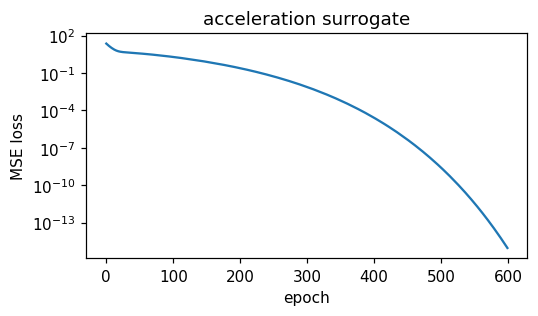

In [4]:
torch.manual_seed(0)
# a = g - c v is linear in the newest velocity window entry - a linear
# model represents it exactly (swap in an MLP/MeshGraphNet for real physics)
model = torch.nn.Linear(3, 3).double()

# flatten particles into rows: each particle is one regression sample
inputs = torch.cat([dataset[i][0] for i in range(len(dataset))])
targets = torch.cat([dataset[i][1] for i in range(len(dataset))])
history = training_utils.TrainModel(
    model, torch.utils.data.TensorDataset(inputs, targets), Kratos.Parameters("""{
        "epochs"        : 600,
        "batch_size"    : 512,
        "learning_rate" : 1e-2,
        "device"        : "auto",
        "seed"          : 0
    }"""))
print(f"final training loss: {history[-1]:.3e}")

plt.figure(figsize=(5, 3))
plt.semilogy(history)
plt.xlabel("epoch"); plt.ylabel("MSE loss"); plt.title("acceleration surrogate")
plt.tight_layout(); plt.show()

## Deployment: autoregressive rollout on a Kratos model part

The trained per-particle model deploys through the `"tensor"` interface
(`model(nodes, edges, edge_index)`), wrapped so it ignores the graph inputs.
`ParticleInferenceProcess` rebuilds the radius graph each step, feeds the
velocity window and moves the nodes with the predicted accelerations.

mean position error after 30 autoregressive steps: 1.043e-08


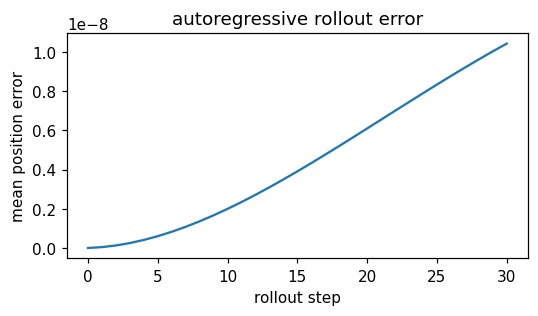

In [5]:
class TensorInterface(torch.nn.Module):
    def __init__(self, trunk):
        super().__init__()
        self.trunk = trunk

    def forward(self, nodes, edges, edge_index):
        return self.trunk(nodes)

checkpoint = workdir / "particle_surrogate.pt"
torch.jit.script(TensorInterface(model.cpu())).save(str(checkpoint))

kratos_model = Kratos.Model()
particles = kratos_model.CreateModelPart("Particles")
for variable in (Kratos.VELOCITY, Kratos.ACCELERATION, Kratos.DISPLACEMENT):
    particles.AddNodalSolutionStepVariable(variable)
particles.SetBufferSize(2)
x0 = rng.random((20, 3))
for i, xyz in enumerate(x0):
    particles.CreateNewNode(i + 1, *xyz)
particles.ProcessInfo[Kratos.DELTA_TIME] = DT

from KratosMultiphysics.PhysicsNeMoApplication import particle_inference_process
process = particle_inference_process.Factory(Kratos.Parameters("""{
    "Parameters": {
        "model_part_name" : "Particles",
        "model_settings"  : { "checkpoint_file" : "%s", "device" : "auto" },
        "model_interface" : "tensor",
        "connectivity"    : { "type" : "radius", "radius" : 0.4 },
        "history_size"    : 1
    }
}""" % checkpoint), kratos_model)

reference = simulate(x0, steps=31)
surrogate_positions = [x0.copy()]
for step in range(1, 31):
    particles.ProcessInfo[Kratos.STEP] = step
    process.ExecuteFinalizeSolutionStep()
    surrogate_positions.append(
        numpy.array([[node.X, node.Y, node.Z] for node in particles.Nodes]))
surrogate_positions = numpy.stack(surrogate_positions)

errors = numpy.linalg.norm(surrogate_positions - reference, axis=-1).mean(axis=1)
print(f"mean position error after 30 autoregressive steps: {errors[-1]:.3e}")

plt.figure(figsize=(5, 3))
plt.plot(errors)
plt.xlabel("rollout step"); plt.ylabel("mean position error")
plt.title("autoregressive rollout error"); plt.tight_layout(); plt.show()
assert errors[-1] < 5e-3

## Takeaways

- `particle_bridge` returns `graph_bridge.BuildGraph`'s exact contract, so
  the whole graph toolchain (PyG conversion, scatter, MeshGraphNet) applies
  to particle clouds unchanged; neighbor search is warp-accelerated with an
  exact numpy fallback.
- The deployment integrator (semi-implicit Euler on `DELTA_TIME`) matches
  the Learning-to-Simulate convention — train targets with the same
  discretization (`CreateParticleTrajectoryDataset` does).
- Record `connectivity_radius`, `history_size` and the dataset's
  normalization statistics in the model card so deployment matches training.